# Tokenization - Aarabhi Kuchi

This notebook prepares contract text for the TF-IDF baseline.
1. Loads one row per contract from CUAD's official train/test split
2. Builds and tests a word tokenizer (`tokenize_words`)
3. Tests the tokenizer on real clauses highlighted by lawyers
4. Explores word frequencies and contract length

In [1]:
import json, re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load one row per contract

In the flattened Q&A tables, each contract's full text is repeated for all 41 clause questions. For tokenization, I only need each contract's text once, so I will pull one row per contract (title + context) straight from the JSON.

In [2]:
with open('../data/train_separate_questions.json', 'r') as file:
    train_json = json.load(file)
with open('../data/test.json', 'r') as file:
    test_json = json.load(file)

In [3]:
def get_contracts(cuad_json):
    contracts = []
    for contract in cuad_json['data']:
        for paragraph in contract['paragraphs']:
            contracts.append({"title": contract['title'], "context": paragraph['context']})
    return pd.DataFrame(contracts)

In [4]:
train_contracts = get_contracts(train_json)
test_contracts = get_contracts(test_json)

In [5]:
train_contracts.shape

(408, 2)

In [6]:
test_contracts.shape

(102, 2)

In [7]:
train_contracts['title'].is_unique

True

In [8]:
test_contracts['title'].is_unique

True

In [9]:
train_contracts.head(5)

,title,context
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,EXHIBIT 10.6\n\n ...
1,"WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION A...",Exhibit 10.26 CONFIDENTIAL TREATMENT HAS BE...
2,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT,Exhibit 1\n\nJOINT FILING AGREEMENT\n\nThe und...
3,ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT A...,REDACTED COPY\n\nCONFIDENTIAL TREATMENT REQUES...
4,"KIROMICBIOPHARMA,INC_05_11_2020-EX-10.23-CONSU...",Exhibit 10.23 Corporate Address Fannin South P...


In [10]:
train_contracts['context'].str.len().describe()

count       408.000000
mean      53991.710784
std       55985.180326
min        1081.000000
25%       16569.750000
50%       35960.500000
75%       68439.750000
max      338211.000000
Name: context, dtype: float64

Contracts range from about 1,081 to 338,211 characters, with a median of 35,960. The mean (~54,000) is above the median, so most contracts are moderate in length and a few very long ones pull the average up. A transformer can only read about 512 tokens (~2,000 characters) at once, so a typical contract is 15–20x too long. This is why chunking is needed.

## 2. Tokenizer

`tokenize_words(text)` turns contract text into a list of lowercase word tokens for the TF-IDF baseline.

**Choices:**
- **Lowercase** everything, so "Agreement" and "agreement" count as the same word.
- **Hyphenated and possessive words stay whole:** `non-compete`, `third-party`, `party's`.
- **Dollar amounts become `<money>`**, including the whole number (e.g. `$1,000,000` or `$ 500,000`). The exact amount rarely matters, but *whether a clause mentions money* is a signal for clauses like Cap On Liability, Minimum Commitment and Revenue/Profit Sharing.
- **Other numbers become one `<num>` token**, including numbers with periods or commas (e.g. `10.6`, `2,500`). Section numbers, days and percentages don't identify a clause type, so the exact value would only add noise.
- **Punctuation is dropped.**
- **No stopwords are removed** (see the note below).

In [11]:
TOKEN_PATTERN = r"\$\s*\d+(?:[.,]\d+)*|\d+(?:[.,]\d+)*|[a-z]+(?:[-'][a-z]+)*"
#   \$\s*\d+(?:[.,]\d+)*   -> dollar amounts, e.g. $1,000,000 or $ 500,000
#   \d+(?:[.,]\d+)*        -> other numbers (one token even with . or ,), e.g. 10.6 or 2,500
#   [a-z]+(?:[-'][a-z]+)*  -> words, incl. non-compete and party's

In [12]:
def tokenize_words(text):
    tokens = re.findall(TOKEN_PATTERN, text.lower())
    cleaned = []
    for token in tokens:
        if token.startswith("$"):
            cleaned.append("<money>")
        elif token[0].isdigit():
            cleaned.append("<num>")
        else:
            cleaned.append(token)
    return cleaned

### Testing for edge cases

In [13]:
tokenize_words("The Licensee shall NOT assign this Non-Compete Agreement within 30 days.")

['the',
 'licensee',
 'shall',
 'not',
 'assign',
 'this',
 'non-compete',
 'agreement',
 'within',
 '<num>',
 'days']

In [14]:
tokenize_words("Section 10.6 of this Agreement")


['section', '<num>', 'of', 'this', 'agreement']

In [15]:
tokenize_words("a fee of $1,000,000")

['a', 'fee', 'of', '<money>']

In [16]:
tokenize_words("liability shall not exceed $ 500,000 or 10% of fees")

['liability', 'shall', 'not', 'exceed', '<money>', 'or', '<num>', 'of', 'fees']

In [17]:
tokenize_words("the Party's third-party rights under Section 2(ii)")

['the', "party's", 'third-party', 'rights', 'under', 'section', '<num>', 'ii']

The edge cases work as intended:
- `not` and `non-compete` stay intact.
- Full dollar amounts become a single `<money>` token, even with commas or a space after the `$`.
- Numbers with periods, like `10.6`, become a single `<num>` token instead of being split into two.
- Percentages become `<num>`; the `%` sign is dropped.

**Known limits:** list markers like `(ii)` still come through as `ii`, dates like `12/31/2020` become three `<num>` tokens, and `U.S.` splits into `u` and `s`. All are low impact for clause detection.

### Stopwords

No stopwords are removed in the tokenizer, for three reasons:
1. TF-IDF already gives near-zero weight to words that appear in almost every contract (e.g. "the", "agreement", "party").
2. If filtering is needed later, it can be done at the TF-IDF step, tuned to contracts rather than a generic English list.
3. The October transformer model should see the full text, so keeping the same rule here keeps both models consistent.

**Words that must never be removed**, even if a stopword list is used later:

| Type | Words | Why it matters |
|---|---|---|
| Negations | not, no, nor, neither, never, without | "shall **not** assign" means the opposite of "shall assign" |
| Obligation | shall, must, will | marks something a party is *required* to do |
| Permission | may, can | marks something a party is *allowed* to do |
| Limits | only, except, unless, solely | define exceptions and restrictions (e.g. exclusivity, caps) |

## 3. Test on Real Clauses

To check that the tokenizer works on real legal text, I pull the clause snippets lawyers highlighted for a few categories and tokenize them. The category name is inside quotes in each question, so I extract it with a regex.

In [18]:
def get_category(question):
    # e.g. 'Highlight the parts (if any) of this contract related to "Governing Law" ...' -> 'Governing Law'
    match = re.search(r'"([^"]+)"', question)
    if match:
        return match.group(1)
    return None

List of all Categories

In [19]:
categories = sorted({get_category(qa['question'])
                     for contract in train_json['data']
                     for paragraph in contract['paragraphs']
                     for qa in paragraph['qas']})
print(len(categories))   # expect 41
categories

41


['Affiliate License-Licensee',
 'Affiliate License-Licensor',
 'Agreement Date',
 'Anti-Assignment',
 'Audit Rights',
 'Cap On Liability',
 'Change Of Control',
 'Competitive Restriction Exception',
 'Covenant Not To Sue',
 'Document Name',
 'Effective Date',
 'Exclusivity',
 'Expiration Date',
 'Governing Law',
 'Insurance',
 'Ip Ownership Assignment',
 'Irrevocable Or Perpetual License',
 'Joint Ip Ownership',
 'License Grant',
 'Liquidated Damages',
 'Minimum Commitment',
 'Most Favored Nation',
 'No-Solicit Of Customers',
 'No-Solicit Of Employees',
 'Non-Compete',
 'Non-Disparagement',
 'Non-Transferable License',
 'Notice Period To Terminate Renewal',
 'Parties',
 'Post-Termination Services',
 'Price Restrictions',
 'Renewal Term',
 'Revenue/Profit Sharing',
 'Rofr/Rofo/Rofn',
 'Source Code Escrow',
 'Termination For Convenience',
 'Third Party Beneficiary',
 'Uncapped Liability',
 'Unlimited/All-You-Can-Eat-License',
 'Volume Restriction',
 'Warranty Duration']

Getting the clause snippets for one category

In [20]:
def get_clauses(cuad_json, category):
    clauses = []
    for contract in cuad_json['data']:
        for paragraph in contract['paragraphs']:
            for qa in paragraph['qas']:
                if get_category(qa['question']) == category:
                    for answer in qa['answers']:
                        clauses.append({"title": contract['title'], "clause": answer['text']})
    return pd.DataFrame(clauses)

Testing on two categories

In [21]:
government_clauses = get_clauses(train_json, "Governing Law")
cap_clauses = get_clauses(train_json, "Cap On Liability")

print("Governing Law Clauses:", len(government_clauses))
print("Cap On Liability Clauses:", len(cap_clauses))

Governing Law Clauses: 374
Cap On Liability Clauses: 554


In [22]:
for text in government_clauses['clause'].head(3):
    print(text)
    print(tokenize_words(text))
    print("-" * 80)

This Agreement is to be construed according to the laws          of the State of Illinois.
['this', 'agreement', 'is', 'to', 'be', 'construed', 'according', 'to', 'the', 'laws', 'of', 'the', 'state', 'of', 'illinois']
--------------------------------------------------------------------------------
This Agreement is governed by English law and the parties submit to the exclusive jurisdiction of the English courts in  relation to any dispute (contractual or non-contractual) concerning this Agreement save that either party may apply to any court for an  injunction or other relief to protect its Intellectual Property Rights.
['this', 'agreement', 'is', 'governed', 'by', 'english', 'law', 'and', 'the', 'parties', 'submit', 'to', 'the', 'exclusive', 'jurisdiction', 'of', 'the', 'english', 'courts', 'in', 'relation', 'to', 'any', 'dispute', 'contractual', 'or', 'non-contractual', 'concerning', 'this', 'agreement', 'save', 'that', 'either', 'party', 'may', 'apply', 'to', 'any', 'court', 'for',

In [23]:
for text in cap_clauses['clause'].head(3):
    print(text)
    print(tokenize_words(text))
    print("-" * 80)

Subject to Clauses 9.1 and 9.2, neither party shall be liable under this Agreement (whether in contract, tort or otherwise) for any:

  (a) loss of anticipated savings;

  (b) loss of business opportunity (which for the avoidance of doubt shall not include loss of advertising revenue);

  (c) loss of or corruption of data;

  (d) loss or damage resulting from third party claims; or

  (e) indirect or consequential losses;
     suffered or incurred by the other party (whether or not such losses were within the contemplation of the parties at the date of this  Agreement).
['subject', 'to', 'clauses', '<num>', 'and', '<num>', 'neither', 'party', 'shall', 'be', 'liable', 'under', 'this', 'agreement', 'whether', 'in', 'contract', 'tort', 'or', 'otherwise', 'for', 'any', 'a', 'loss', 'of', 'anticipated', 'savings', 'b', 'loss', 'of', 'business', 'opportunity', 'which', 'for', 'the', 'avoidance', 'of', 'doubt', 'shall', 'not', 'include', 'loss', 'of', 'advertising', 'revenue', 'c', 'loss', 'o

Governing Law clauses are short and consistent ("governed by the laws of the State of Illinois"), so they should be easy to detect from words like *governed*, *laws* and *state*. Cap On Liability clauses are longer and more varied. Things I noticed:
- **Amounts are often redacted.** CUAD contracts were made public with sensitive values replaced by `[ * ]`, so many caps show no dollar amount. `<money>` will help less than expected for this category.
- **Clause references become `<num>`** ("Subject to Clauses 9.1 and 9.2" becomes `<num> and <num>`), which is fine.
- **List markers become single letters** (`(b)`, `(c)`, `(d)` become `b`, `c`, `d`). This is minor noise.
- **Some Cap On Liability clauses are really exclusions** ("neither party shall be liable ... for indirect or consequential losses"), so the category covers more than just a capped amount.

## 4. Exploratory Data Analysis

### Most frequent words
`count` is the total number of times a word appears across all training contracts. `% of contracts` is the share of contracts that contain it at least once.

In [24]:
word_counts = Counter()   # total times each word appears
doc_counts = Counter()    # number of contracts each word appears in
for text in train_contracts['context']:
    tokens = tokenize_words(text)
    word_counts.update(tokens)
    doc_counts.update(set(tokens))

top = pd.DataFrame(word_counts.most_common(30), columns=['word', 'count'])
top['% of contracts'] = (top['word'].map(doc_counts) / len(train_contracts) * 100).round(1)
top

,word,count,% of contracts
0,the,209154,100.0
1,of,126446,100.0
2,<num>,113548,100.0
3,and,107720,100.0
4,to,106557,100.0
5,or,88329,98.8
6,in,65095,99.8
7,any,50555,97.8
8,a,44150,99.0
9,shall,39805,98.0


Common English words (*the, of, and, to*) appear in nearly 100% of contracts, as expected. `<num>` is one of the most common tokens, so numbers are everywhere in contracts.

**Important:** the protected words are also near the top. *not* appears in about 97% of contracts, *shall* in about 98%, *may* in about 97% and *will* in about 94%. So a frequency cut-off (like `max_df=0.9` in TF-IDF) applied to whole contracts would **remove exactly the words we need to keep**. This supports not removing stopwords. If frequency filtering is ever used, it must be checked at the chunk level, or the protected words must be excluded from removal.

### Contract Length in Words

In [25]:
train_contracts['n_words'] = train_contracts['context'].apply(lambda t: len(tokenize_words(t)))
train_contracts['n_words'].describe()

count      408.000000
mean      8064.973039
std       8270.826461
min        177.000000
25%       2575.500000
50%       5407.500000
75%      10474.250000
max      45968.000000
Name: n_words, dtype: float64

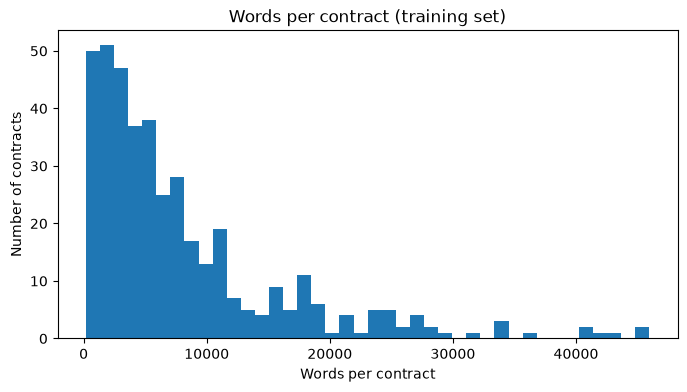

In [26]:
plt.figure(figsize=(8, 4))
plt.hist(train_contracts['n_words'], bins=40)
plt.title("Words per contract (training set)")
plt.xlabel("Words per contract")
plt.ylabel("Number of contracts")
plt.show()

In [27]:
n = train_contracts['n_words']
print(f"Shortest contract: {n.min():,} words")
print(f"Longest contract:  {n.max():,} words")
print(f"Median contract:   {int(n.median()):,} words")
print(f"75% of contracts are under {int(n.quantile(0.75)):,} words")
print(f"With ~300-word chunks, a median contract becomes about {round(n.median() / 300)} chunks")

Shortest contract: 177 words
Longest contract:  45,968 words
Median contract:   5,407 words
75% of contracts are under 10,474 words
With ~300-word chunks, a median contract becomes about 18 chunks


The histogram is right-skewed: most contracts are moderate in length, but a small number of very long contracts stretch the tail (see the numbers above). Even the median contract is far too long for a model to read at once, so it will be split into many ~300-word chunks. Very long contracts will produce many chunks, most of which contain no labeled clause, which adds to the class imbalance the model has to handle.

## 5. Summary

**What this notebook does:** loads one row per contract from CUAD's official split (408 train / 102 test), builds and tests a word tokenizer for the TF-IDF baseline, and explores word frequencies and contract length.

**Tokenizer choices:**
- lowercase; hyphenated and possessive words kept whole
- dollar amounts become `<money>`; other numbers (including ones like `10.6`) become one `<num>` token; punctuation removed
- no stopwords removed; negations and modal words (*not, shall, may, must, except*) must always be kept

**Key findings:**
- Contracts range from 177 to 45,968 words (median 5,407), so a median contract becomes about 18 chunks of ~300 words, which is why contracts must be chunked.
- Governing Law clauses are short and formulaic, while Cap On Liability clauses are long, varied and often have redacted amounts.
- Protected words like *not*, *shall* and *may* appear in 94–98% of contracts, so contract-level frequency filtering would remove them.